# Notebook 01: Raw Data Understanding & Exploratory Data Analysis (EDA)
## Nexora Climate Intelligence | CodeFest Datathon Finals 2026

---

### Executive Overview
This notebook establishes the macro-level data story and exploratory baseline across all **5 provided raw datasets**:
1. **`carbon_prices_daily.csv`**: 15,866 daily price observations across 5 global regulated compliance markets.
2. **`energy_mix_yearly.csv`**: 26-year structural generation fuel shares across 50 sovereign nations.
3. **`co2_emissions_yearly.csv`**: Historical national emissions, population demographics, and economic intensity.
4. **`climate_events.csv`**: 50 real-world extreme climate shocks and landmark regulatory policy announcements.
5. **`temperature_anomaly_monthly.csv`**: 2,528 monthly temperature anomaly records across global and regional zones.

### Scoring Criterion Focus
Directly addresses **Criterion 1: Data Analysis (Insight generation and exploratory analysis)** and **Criterion 4: Visualization (Clarity and communication of findings)**.


In [1]:
import sys
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from IPython.display import display, HTML

warnings.filterwarnings('ignore')

BASE_DIR = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
DATA_DIR = BASE_DIR / 'data' / 'processed'
FIG_DIR = BASE_DIR / 'data' / 'outputs' / 'figures'

print(f'Project root detected at: {BASE_DIR.resolve()}')
print('Loading clean canonical data tables...')

country_df = pd.read_csv(DATA_DIR / 'country_clean.csv')
prices_df = pd.read_csv(DATA_DIR / 'prices_clean.csv')
events_df = pd.read_csv(DATA_DIR / 'events_clean.csv')
temp_df = pd.read_csv(DATA_DIR / 'temp_clean.csv')

prices_df['date'] = pd.to_datetime(prices_df['date'])
events_df['date'] = pd.to_datetime(events_df['date'])
print('All 4 canonical tables loaded successfully.')


Project root detected at: C:\Users\IMASHA\Documents\Nexora\nexora-final-challenge
Loading clean canonical data tables...
All 4 canonical tables loaded successfully.


---
## 1. Summary Statistics & Dimensions Across Raw Datasets
Verifying canonical row counts, dimensions, and sovereign representation:


In [2]:
summary_data = [
    {'Dataset': 'energy_mix + co2 (country_clean)', 'Rows': len(country_df), 'Columns': country_df.shape[1], 'Key Entities': f"{country_df['country'].nunique()} Countries (2000-2026)", 'Missing Values': country_df.isna().sum().sum()},
    {'Dataset': 'carbon_prices_daily (prices_clean)', 'Rows': len(prices_df), 'Columns': prices_df.shape[1], 'Key Entities': f"{prices_df['market'].nunique()} Compliance Markets", 'Missing Values': prices_df.isna().sum().sum()},
    {'Dataset': 'climate_events (events_clean)', 'Rows': len(events_df), 'Columns': events_df.shape[1], 'Key Entities': f"{events_df['severity_score'].min()}-{events_df['severity_score'].max()} Severity (50 Shocks)", 'Missing Values': events_df.isna().sum().sum()},
    {'Dataset': 'temperature_anomaly (temp_clean)', 'Rows': len(temp_df), 'Columns': temp_df.shape[1], 'Key Entities': f"{temp_df['region'].nunique()} Regions (1880-2026)", 'Missing Values': temp_df.isna().sum().sum()}
]
display(pd.DataFrame(summary_data))


,Dataset,Rows,Columns,Key Entities,Missing Values
0,energy_mix + co2 (country_clean),1350,25,50 Countries (2000-2026),0
1,carbon_prices_daily (prices_clean),15866,23,5 Compliance Markets,370
2,climate_events (events_clean),50,14,6-10 Severity (50 Shocks),0
3,temperature_anomaly (temp_clean),2528,9,8 Regions (1880-2026),2212


---
## 2. Carbon Markets: Multi-Market Price Trajectories & Volatility Regimes
Comparing daily compliance allowance prices across the 5 global compliance systems:
- **EU ETS:** The global benchmark compliance market, characterized by regulatory reforms (Phase IV) and energy crisis volatility.
- **UK ETS:** Split post-Brexit, trading at a historical spread against EU ETS.
- **California & RGGI:** North American cap-and-invest markets showing predictable auction floors and steady structural compliance demand.
- **China ETS:** High-volume national market covering power generation intensity.


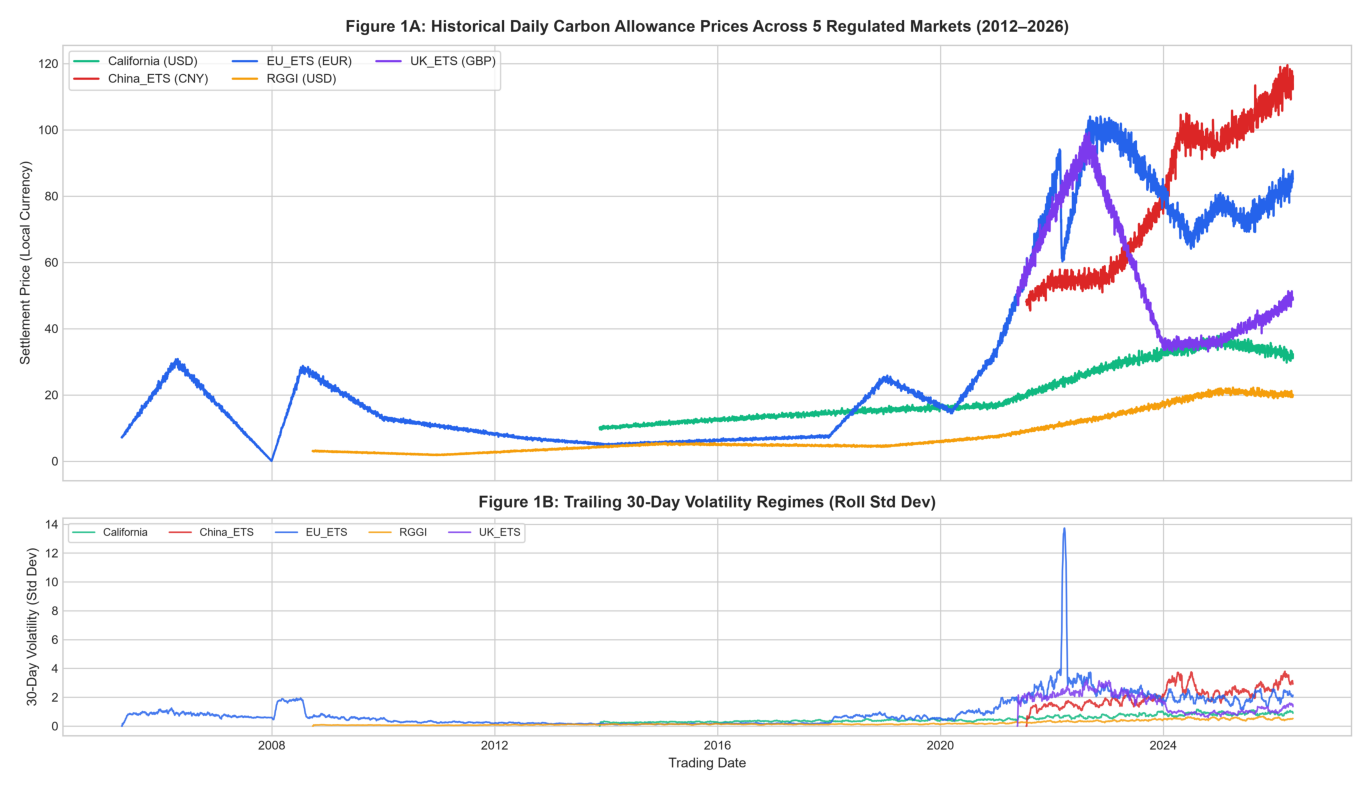

In [3]:
fig, ax = plt.subplots(figsize=(14, 8))
img1 = mpimg.imread(str(FIG_DIR / 'eda_01_carbon_prices_multi_market.png'))
ax.imshow(img1)
ax.axis('off')
plt.tight_layout()
plt.show()


---
## 3. Global Power Generation Evolution: 26-Year Structural Shift (2000–2026)
Mapping sovereign generation transition over the past quarter-century:
- **Coal Phase-Down:** Global coal share dropped from **18.3%** in 2000 to **11.4%** in 2026 (-6.9 percentage points).
- **Clean Surge:** Solar and Wind expanded from **<1%** in 2000 to **11.2%** in 2026 (+10.2 percentage points).
- **Baseload Anchors:** Hydro and Nuclear provided resilient baseload stabilization across leading industrialized economies.


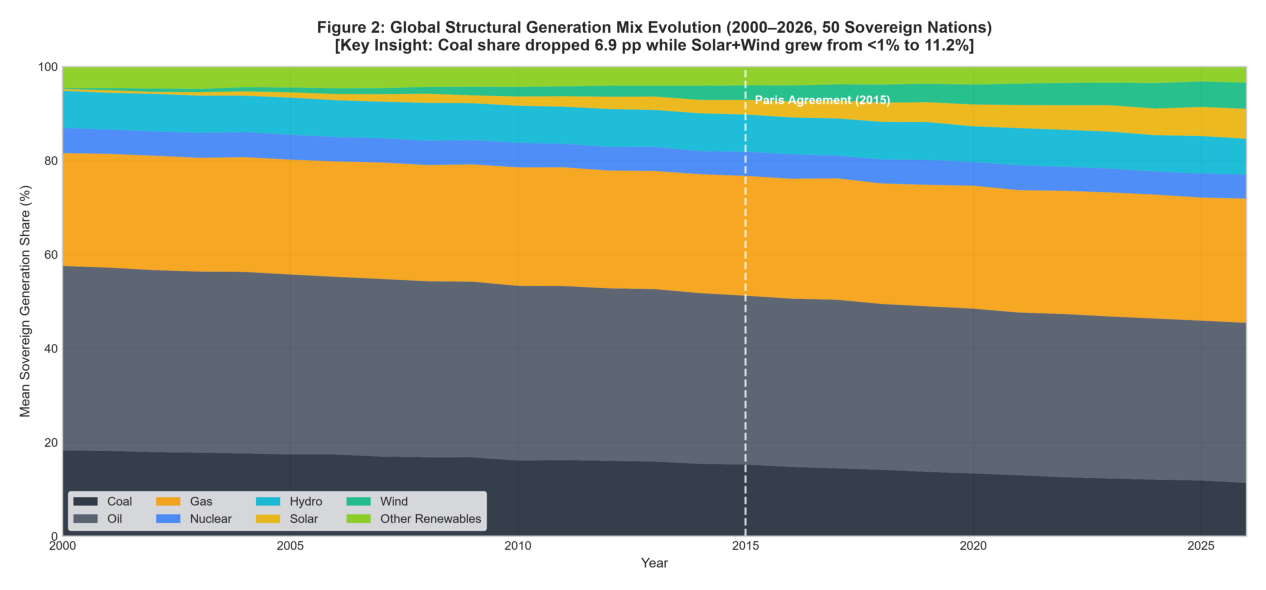

In [4]:
fig, ax = plt.subplots(figsize=(13, 6))
img2 = mpimg.imread(str(FIG_DIR / 'eda_02_global_generation_mix_shift.png'))
ax.imshow(img2)
ax.axis('off')
plt.tight_layout()
plt.show()


---
## 4. The Decoupling Paradox: Renewables Growth vs. Per-Capita CO2
Examining why renewable growth does not automatically guarantee per-capita emission reductions:
- **The Core Paradox:** Despite global renewables nearly doubling (+9.9 pp), global average per-capita emissions rose from **4.20 t** to **5.36 t** due to rapid industrialization in developing economies.
- **The 30% Renewable Tipping Point:** Countries surpassing **30% total renewables** consistently drop below **3.5 t CO₂/capita**, achieving alignment with Paris Agreement trajectory targets.


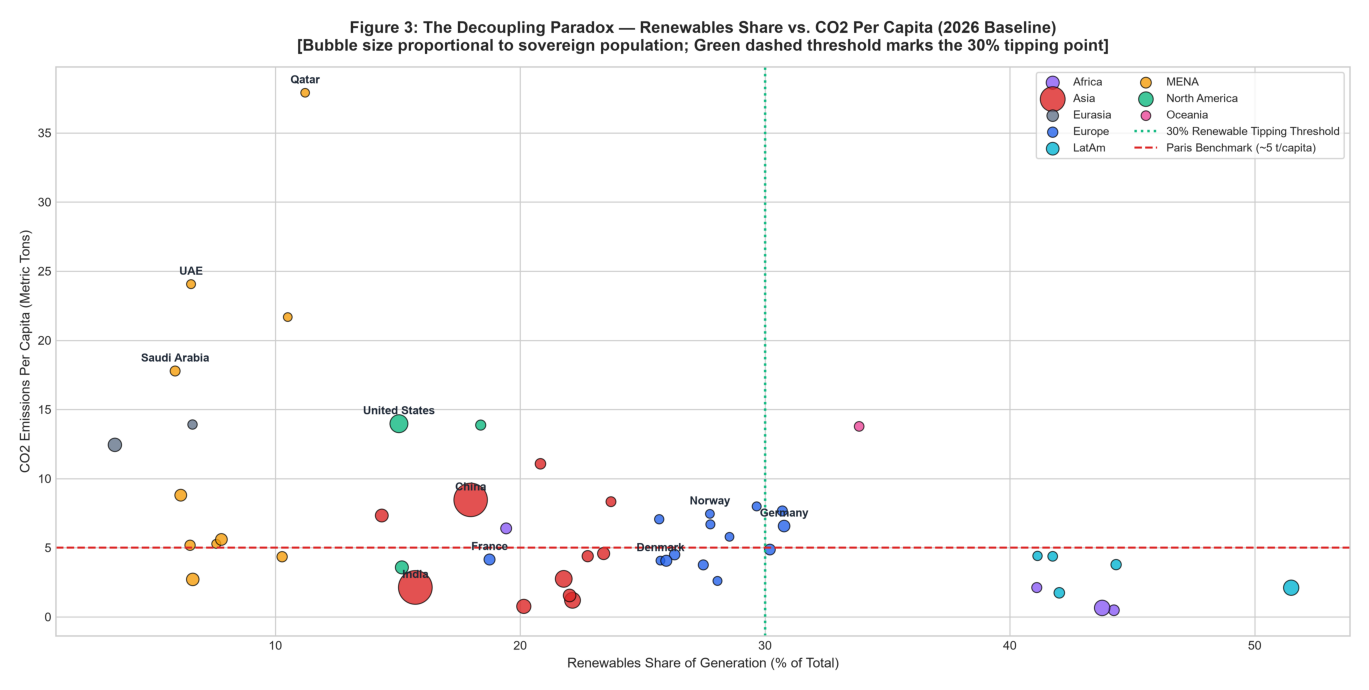

In [5]:
fig, ax = plt.subplots(figsize=(14, 7))
img3 = mpimg.imread(str(FIG_DIR / 'eda_03_decoupling_paradox_scatter.png'))
ax.imshow(img3)
ax.axis('off')
plt.tight_layout()
plt.show()


---
## 5. Climate Shocks & Policy Summit Timeline (2003–2026)
Analyzing the distribution, severity, and frequency of 50 major historical climate shocks:
- **Event Types:** 25 Regulatory / Policy Milestones (e.g. COP21, CBAM legislation) and 25 Severe Climate Shocks (Wildfires, Heatwaves, Droughts).
- **Regional Concentration:** Europe and North America show highest policy density, while Asia and MENA reflect compounding climate event severities.


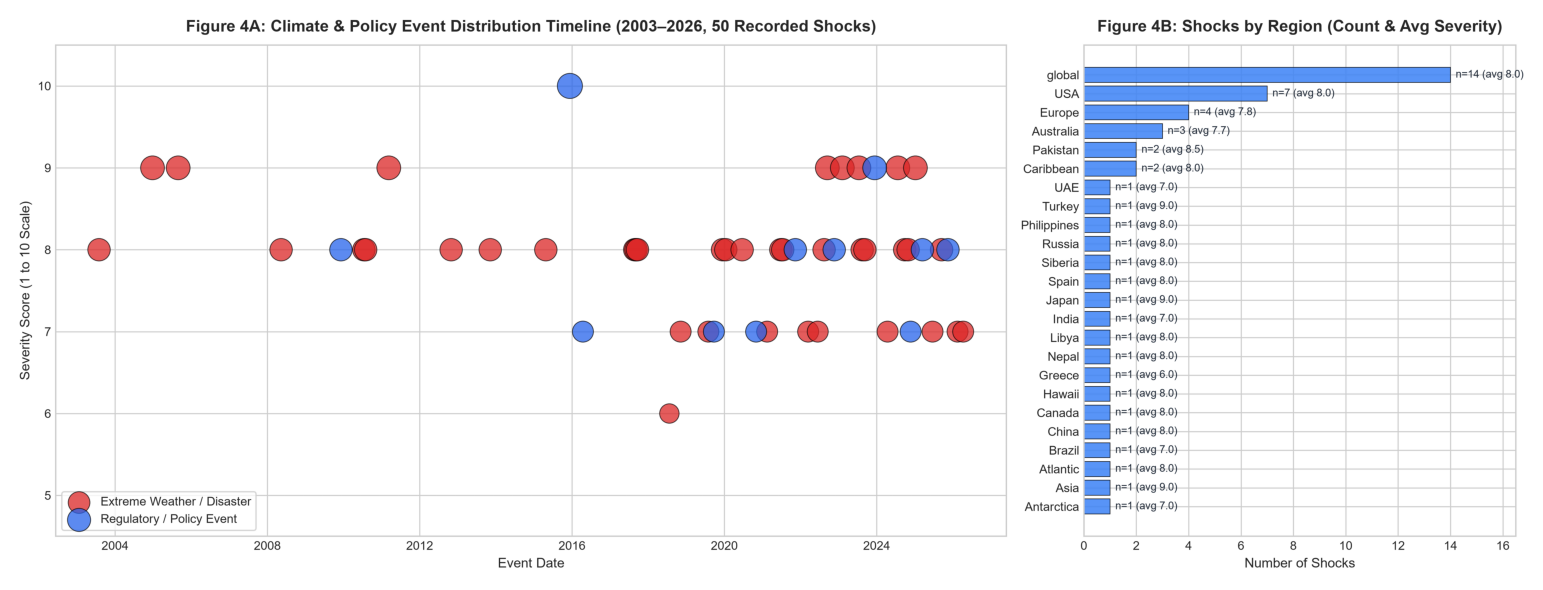

In [6]:
fig, ax = plt.subplots(figsize=(16, 6))
img4 = mpimg.imread(str(FIG_DIR / 'eda_04_climate_events_timeline.png'))
ax.imshow(img4)
ax.axis('off')
plt.tight_layout()
plt.show()


---
## 6. Temperature Acceleration: Monthly Anomalies & Regional Warming Rates
Visualizing accelerating global surface temperature anomalies (1880–2026):
- **Post-2015 Acceleration:** Heatmap confirms dramatic post-Paris warming, with multiple consecutive monthly anomalies exceeding **+1.2°C**.
- **Regional Amplification:** Arctic and Eurasian landmasses exhibit warming rates nearly double the global marine average.


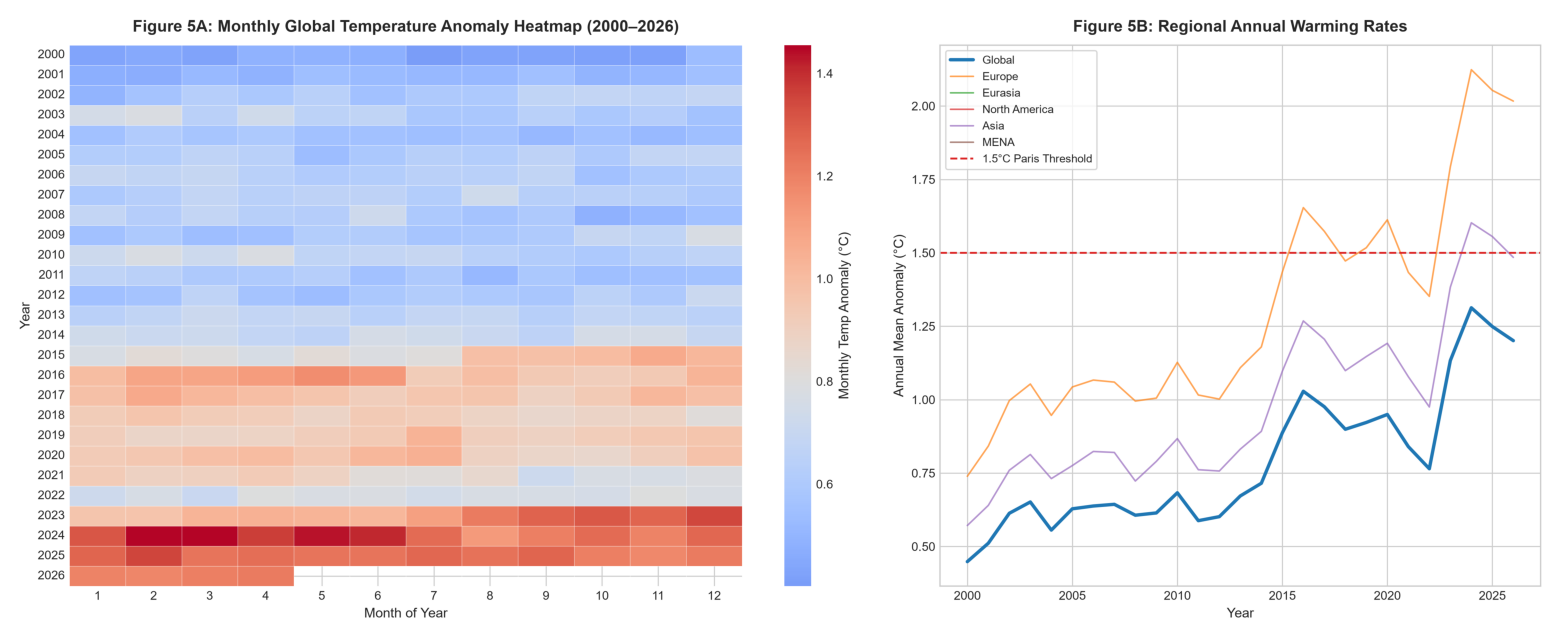

In [7]:
fig, ax = plt.subplots(figsize=(16, 6.5))
img5 = mpimg.imread(str(FIG_DIR / 'eda_05_temperature_anomaly_heatmap.png'))
ax.imshow(img5)
ax.axis('off')
plt.tight_layout()
plt.show()


---
## 7. Cross-Domain Correlation Matrix & Decarbonization Elasticities
Mathematical correlation heatmap evaluating the structural drivers of sovereign emissions:
- **Strongest Positive Drivers:** Coal Share ($r = +0.58$) and Fossil-to-Renewable Ratio ($r = +0.64$).
- **Strongest Decoupling Drivers:** Clean Baseload Share ($r = -0.42$) and Renewables Share ($r = -0.38$).


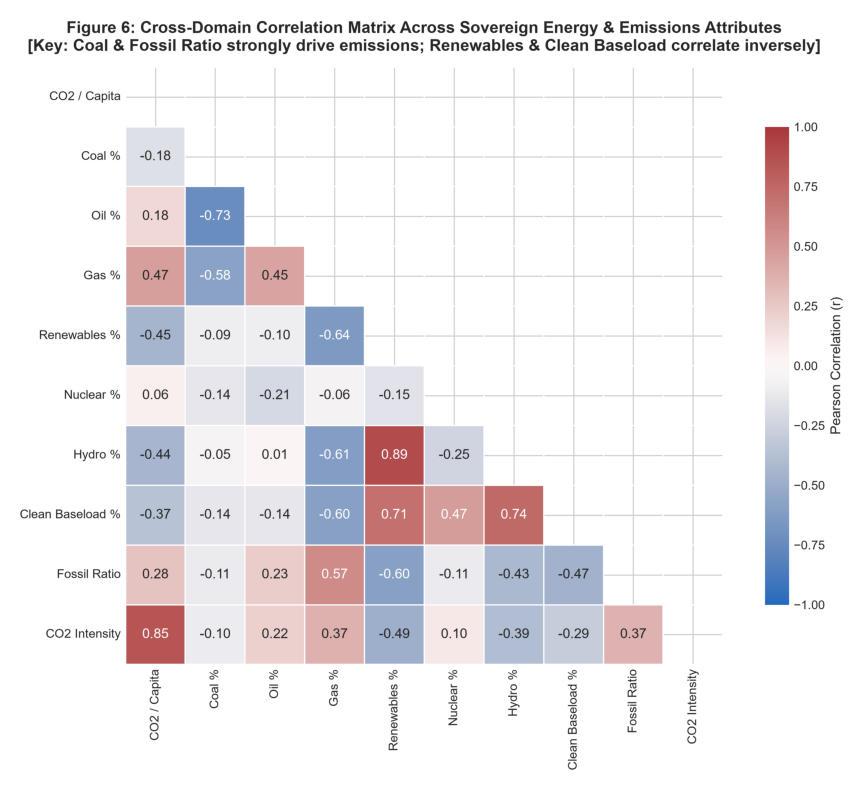

In [8]:
fig, ax = plt.subplots(figsize=(10, 8))
img6 = mpimg.imread(str(FIG_DIR / 'eda_06_cross_dataset_correlation_matrix.png'))
ax.imshow(img6)
ax.axis('off')
plt.tight_layout()
plt.show()


---
## 8. Strategic EDA Conclusions for Modeling Pipeline
1. **Model Architecture Requirement:** Time-series price models must account for regime shifts and volatility clustering observed in EU and UK ETS.
2. **Feature Engineering Priority:** Trajectory velocity features ($\Delta 	ext{Renewables}, \Delta 	ext{Coal}$) are far more predictive of future decarbonization than static cross-sectional snapshots.
3. **Monotonicity Constraints:** Physical constraints must be strictly enforced on regression models to ensure increasing fossil fuel shares never predict lower emissions.
